In [4]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [5]:
warnings.filterwarnings('ignore') 
sns.set_theme(style='whitegrid') 
plt.rcParams['figure.figsize'] = (10, 5)

In [8]:
df = pd.read_csv('digital_marketing_campaign_dataset.csv') 
print('Shape:', df.shape) 
print('\nFirst 5 rows:') 
df.head()

Shape: (8000, 20)

First 5 rows:


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


In [9]:
print('Column data types:')
print(df.dtypes)
print('\nMissing values per column:')
print(df.isnull().sum())
print('\nSample unique values:')
print('CampaignChannel:', df['CampaignChannel'].unique()) 
print('CampaignType:', df['CampaignType'].unique()) 
print('Gender:', df['Gender'].unique())

Column data types:
CustomerID               int64
Age                      int64
Gender                  object
Income                   int64
CampaignChannel         object
CampaignType            object
AdSpend                float64
ClickThroughRate       float64
ConversionRate         float64
WebsiteVisits            int64
PagesPerVisit          float64
TimeOnSite             float64
SocialShares             int64
EmailOpens               int64
EmailClicks              int64
PreviousPurchases        int64
LoyaltyPoints            int64
AdvertisingPlatform     object
AdvertisingTool         object
Conversion               int64
dtype: object

Missing values per column:
CustomerID             0
Age                    0
Gender                 0
Income                 0
CampaignChannel        0
CampaignType           0
AdSpend                0
ClickThroughRate       0
ConversionRate         0
WebsiteVisits          0
PagesPerVisit          0
TimeOnSite             0
SocialShares       

In [10]:
# Remove duplicate rows
df = df.drop_duplicates() 
print('Rows after removing duplicates:', len(df))
# Drop columns that are redacted/useless (both contain 'IsConfid'/'ToolConfid') 
df = df.drop(columns=['AdvertisingPlatform', 'AdvertisingTool'])
# Check for bad values 
print('Negative AdSpend count:', (df['AdSpend'] < 0).sum())
print('Negative Income count:', (df['Income'] < 0).sum())
# Make sure Conversion is integer
df['Conversion'] = df['Conversion'].astype(int)
print('\nCleaning done! Final shape:', df.shape) 
df.head(3)

Rows after removing duplicates: 8000
Negative AdSpend count: 0
Negative Income count: 0

Cleaning done! Final shape: (8000, 18)


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,1


In [11]:
# ROI = how much conversion you get per dollar spent (x1000 to make readable)
df['ROI'] = (df['ConversionRate'] / df['AdSpend']) * 1000
print('ROI column added. Sample:')
df[['CampaignChannel', 'AdSpend', 'ConversionRate', 'ROI']].head(10)

ROI column added. Sample:


,CampaignChannel,AdSpend,ConversionRate,ROI
0,Social Media,6497.870068,0.088031,0.013548
1,Email,3898.668606,0.182725,0.046868
2,PPC,1546.429596,0.076423,0.049419
3,PPC,539.525936,0.088004,0.163114
4,PPC,1678.043573,0.109940,0.065517
5,Social Media,9579.388247,0.161316,0.016840
6,Referral,7302.899852,0.060977,0.008350
7,Social Media,5324.283667,0.188946,0.035488
8,Email,9421.250951,0.112585,0.011950
9,Social Media,6229.193333,0.169786,0.027256


In [12]:
print('Basic statistics for all numeric columns:') 
df.describe().round(2)

Basic statistics for all numeric columns:


,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion,ROI
count,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.0,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00
mean,11999.50,43.63,84664.20,5000.94,0.15,0.10,24.75,5.55,7.73,49.8,9.48,4.47,4.49,2490.27,0.88,0.05
std,2309.55,14.90,37580.39,2838.04,0.08,0.05,14.31,2.61,4.23,28.9,5.71,2.86,2.89,1429.53,0.33,0.10
min,8000.00,18.00,20014.00,100.05,0.01,0.01,0.00,1.00,0.50,0.0,0.00,0.00,0.00,0.00,0.00,0.00
25%,9999.75,31.00,51744.50,2523.22,0.08,0.06,13.00,3.30,4.07,25.0,5.00,2.00,2.00,1254.75,1.00,0.01
50%,11999.50,43.00,84926.50,5013.44,0.15,0.10,25.00,5.53,7.68,50.0,9.00,4.00,4.00,2497.00,1.00,0.02
75%,13999.25,56.00,116815.75,7407.99,0.23,0.15,37.00,7.84,11.48,75.0,14.00,7.00,7.00,3702.25,1.00,0.04
max,15999.00,69.00,149986.00,9997.91,0.30,0.20,49.00,10.00,15.00,99.0,19.00,9.00,9.00,4999.00,1.00,1.79


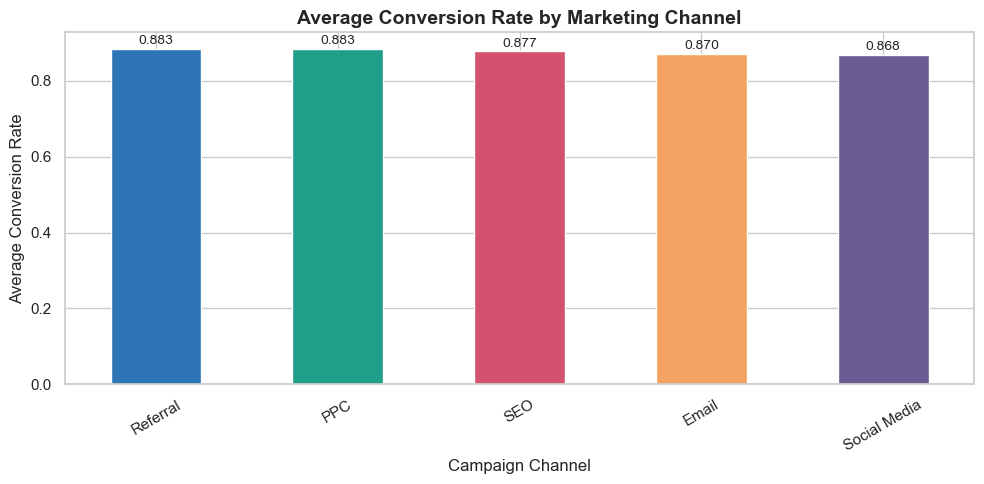

Channel conversion rates:
CampaignChannel
Referral        0.8831
PPC             0.8828
SEO             0.8768
Email           0.8703
Social Media    0.8683
Name: Conversion, dtype: float64


In [13]:
channel_conv = df.groupby('CampaignChannel')['Conversion'].mean().sort_values(ascending=False) 
plt.figure(figsize=(10, 5)) 
ax = channel_conv.plot(kind='bar', color=['#2E75B6','#1F9E89','#D4526E','#F4A261','#6B5B95']) 
plt.title('Average Conversion Rate by Marketing Channel', fontsize=14, fontweight='bold')
plt.xlabel('Campaign Channel')
plt.ylabel('Average Conversion Rate')
plt.xticks(rotation=30)

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout() 
plt.savefig('chart_conversion_by_channel.png', dpi=150, bbox_inches='tight') 
plt.show() 
print('Channel conversion rates:') 
print(channel_conv.round(4))

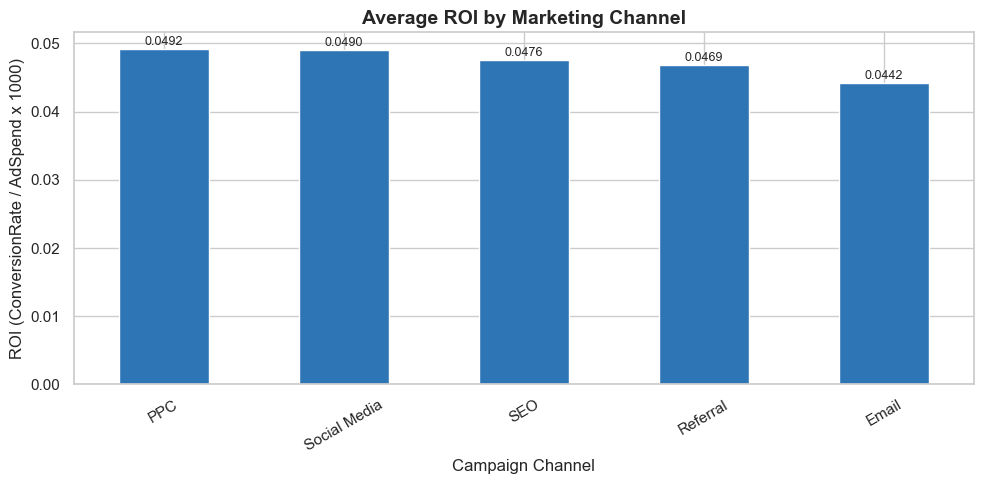

ROI by channel:
CampaignChannel
PPC             0.0492
Social Media    0.0490
SEO             0.0476
Referral        0.0469
Email           0.0442
Name: ROI, dtype: float64


In [15]:
roi_by_channel = df.groupby('CampaignChannel')['ROI'].mean().sort_values(ascending=False) 

plt.figure(figsize=(10, 5))
ax = roi_by_channel.plot(kind='bar', color='#2E75B6') 
plt.title('Average ROI by Marketing Channel', fontsize=14, fontweight='bold')
plt.xlabel('Campaign Channel')
plt.ylabel('ROI (ConversionRate / AdSpend x 1000)')
plt.xticks(rotation=30)

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001, 
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9) 
plt.tight_layout() 
plt.savefig('chart_roi_by_channel.png', dpi=150, bbox_inches='tight')
plt.show() 
print('ROI by channel:') 
print(roi_by_channel.round(4))

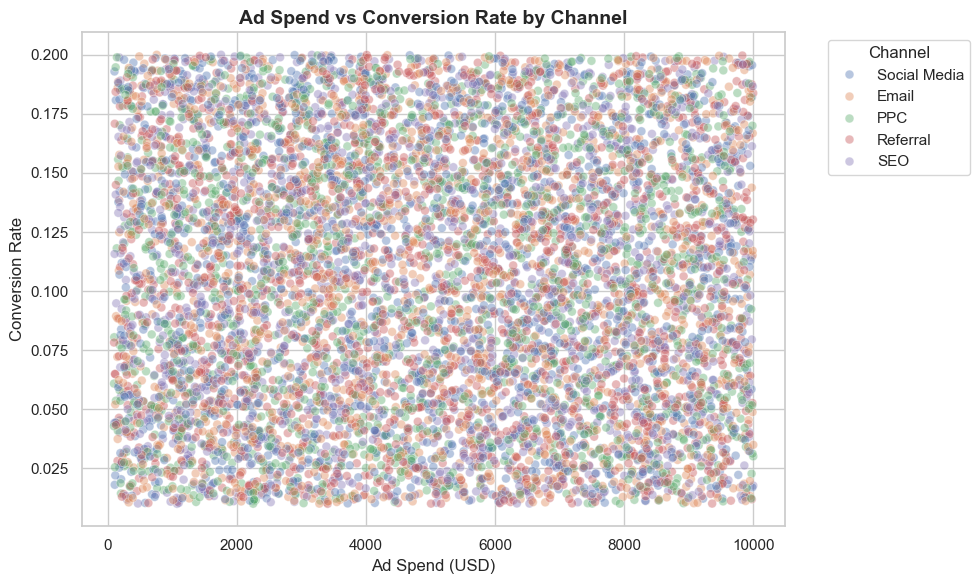

In [16]:
plt.figure(figsize=(10, 6)) 
sns.scatterplot( 
    data=df, 
    x='AdSpend', 
    y='ConversionRate', 
    hue='CampaignChannel', 
    alpha=0.4, 
    s=40 
)

plt.title('Ad Spend vs Conversion Rate by Channel', fontsize=14, fontweight='bold') 
plt.xlabel('Ad Spend (USD)')
plt.ylabel('Conversion Rate')
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1)) 
plt.tight_layout() 
plt.savefig('chart_spend_vs_conversion.png', dpi=150, bbox_inches='tight')
plt.show()

Funnel Summary by Campaign Type:
               TotalCampaigns  AvgClickThrough  AvgConversionRate  TotalConverted
CampaignType                                                                     
Awareness                1988           0.1558             0.1044            1701
Consideration            1988           0.1518             0.1051            1701
Conversion               2077           0.1557             0.1049            1939
Retention                1947           0.1561             0.1032            1671


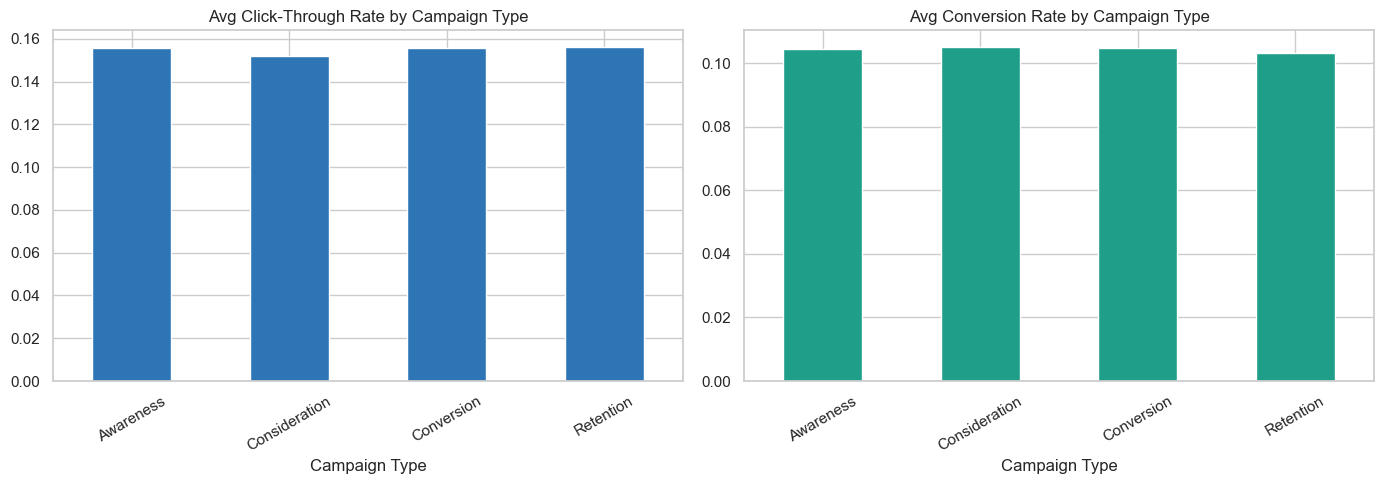

In [17]:
funnel = df.groupby('CampaignType').agg( 
    TotalCampaigns=('CustomerID', 'count'),
    AvgClickThrough=('ClickThroughRate', 'mean'),
    AvgConversionRate=('ConversionRate', 'mean'), 
    TotalConverted=('Conversion', 'sum') ).round(4)

print('Funnel Summary by Campaign Type:')
print(funnel.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

funnel['AvgClickThrough'].plot(kind='bar', ax=axes[0], color='#2E75B6')
axes[0].set_title('Avg Click-Through Rate by Campaign Type') 
axes[0].set_xlabel('Campaign Type') 
axes[0].tick_params(axis='x', rotation=30)

funnel['AvgConversionRate'].plot(kind='bar', ax=axes[1], color='#1F9E89')
axes[1].set_title('Avg Conversion Rate by Campaign Type')
axes[1].set_xlabel('Campaign Type') 
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout() 
plt.savefig('chart_funnel_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

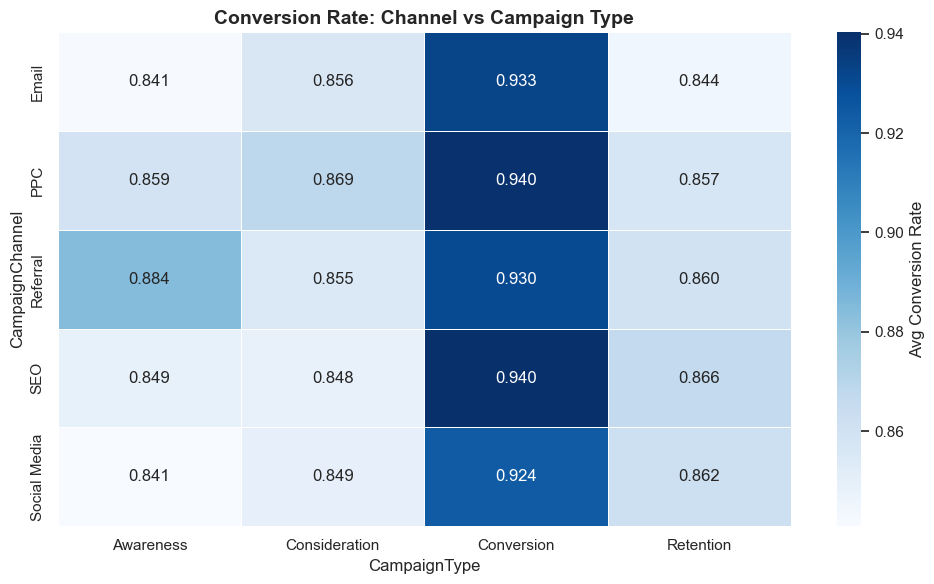

Best combination:
('SEO', 'Conversion') -> 0.9403


In [21]:
pivot = df.pivot_table( values='Conversion', 
                        index='CampaignChannel', 
                        columns='CampaignType',
                        aggfunc='mean' )

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.5, 
            cbar_kws={'label': 'Avg Conversion Rate'}) 
plt.title('Conversion Rate: Channel vs Campaign Type', fontsize=14, fontweight='bold') 
plt.tight_layout()
plt.savefig('chart_heatmap.png', dpi=150, bbox_inches='tight') 
plt.show()

print('Best combination:') 
print(pivot.stack().idxmax(), '->', round(pivot.stack().max(), 4))

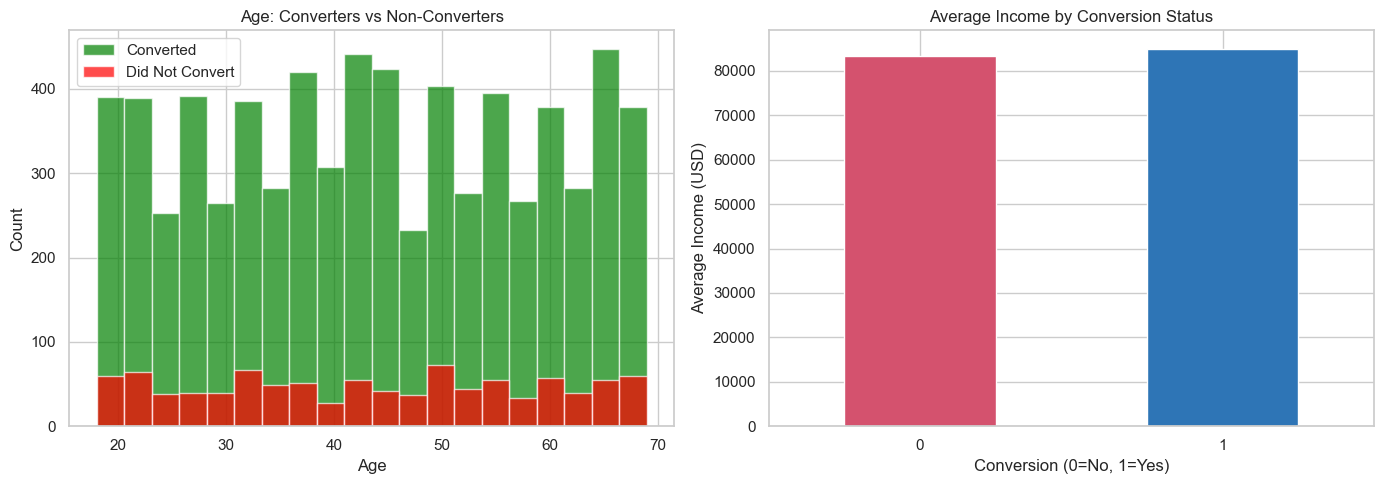

Conversion rate by gender:
Gender
Female    0.8762
Male      0.8769
Name: Conversion, dtype: float64

Average income by conversion:
Conversion
0    83265.31
1    84861.30
Name: Income, dtype: float64


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) 
# Age distribution 
df[df['Conversion']==1]['Age'].hist(ax=axes[0], bins=20, alpha=0.7, color='green', label='Converted') 
df[df['Conversion']==0]['Age'].hist(ax=axes[0], bins=20, alpha=0.7, color='red', label='Did Not Convert') 
axes[0].set_title('Age: Converters vs Non-Converters') 
axes[0].set_xlabel('Age') 
axes[0].set_ylabel('Count')
axes[0].legend()

# Income vs Conversion
df.groupby('Conversion')['Income'].mean().plot( kind='bar', ax=axes[1], color=['#D4526E','#2E75B6']) 
axes[1].set_title('Average Income by Conversion Status') 
axes[1].set_xlabel('Conversion (0=No, 1=Yes)')
axes[1].set_ylabel('Average Income (USD)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('chart_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

print('Conversion rate by gender:')
print(df.groupby('Gender')['Conversion'].mean().round(4)) 
print('\nAverage income by conversion:')
print(df.groupby('Conversion')['Income'].mean().round(2))

In [23]:
# Full cleaned dataset (for detailed Power BI analysis)
df.to_csv('cleaned_marketing_data.csv', index=False) 
# Summary table by channel (for Power BI dashboard cards) 
channel_summary = df.groupby('CampaignChannel').agg( TotalCustomers=('CustomerID', 'count'), TotalConverted=('Conversion', 'sum'), AvgAdSpend=('AdSpend', 'mean'), AvgCTR=('ClickThroughRate', 'mean'), AvgConversionRate=('ConversionRate', 'mean'), AvgROI=('ROI', 'mean'), TotalSpend=('AdSpend', 'sum') ).round(4).reset_index() 
channel_summary['ConversionPct'] = ( channel_summary['TotalConverted'] / channel_summary['TotalCustomers'] * 100 ).round(2) 
channel_summary.to_csv('channel_summary.csv', index=False) 
print('✅ Both files saved to your project folder!')
print('\nChannel Summary:') 
print(channel_summary.to_string())

✅ Both files saved to your project folder!

Channel Summary:
  CampaignChannel  TotalCustomers  TotalConverted  AvgAdSpend  AvgCTR  AvgConversionRate  AvgROI    TotalSpend  ConversionPct
0           Email            1557            1355   5055.6043  0.1556             0.1049  0.0442  7.871576e+06          87.03
1             PPC            1655            1461   4954.2217  0.1583             0.1041  0.0492  8.199237e+06          88.28
2        Referral            1719            1518   5034.0423  0.1517             0.1031  0.0469  8.653519e+06          88.31
3             SEO            1550            1359   4994.1315  0.1532             0.1035  0.0476  7.740904e+06          87.68
4    Social Media            1519            1319   4965.3214  0.1555             0.1066  0.0490  7.542323e+06          86.83
